<a href="https://colab.research.google.com/github/aniray2908/ML-foundations-rebuild/blob/main/interpretability/demos/partial_dependence_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Partial Dependence Demonstration

This notebook explores how Partial Dependence Plots (PDPs) help interpret model behavior.

We demonstrate:

- Linear relationships
- Nonlinear relationships
- Diminishing returns
- Flat relationships
- Overfitting patterns
- Interaction distortion

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay
from sklearn.model_selection import train_test_split

In [37]:
X, y = make_regression(
    n_samples=1000,
    n_features=4,
    noise=10,
    random_state=42
)

feature_names = ["feature_1", "feature_2", "feature_3", "feature_4"]

X = pd.DataFrame(X, columns=feature_names)
X["nonlinear_feature"] = X["feature_1"]**2
X["saturation_feature"] = np.log(np.abs(X["feature_1"]) + 1)
X["negative_feature"] = -X["feature_1"]

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=200, random_state=42)

model.fit(X_train, y_train)

print("Model R²:", model.score(X_test, y_test))

Model R²: 0.9625754451982291


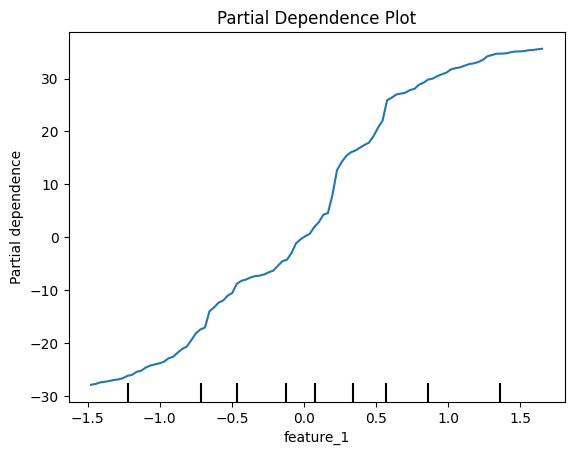

In [39]:
PartialDependenceDisplay.from_estimator(
    model,
    X_test,
    features=[0]
)

plt.title("Partial Dependence Plot")
plt.show()

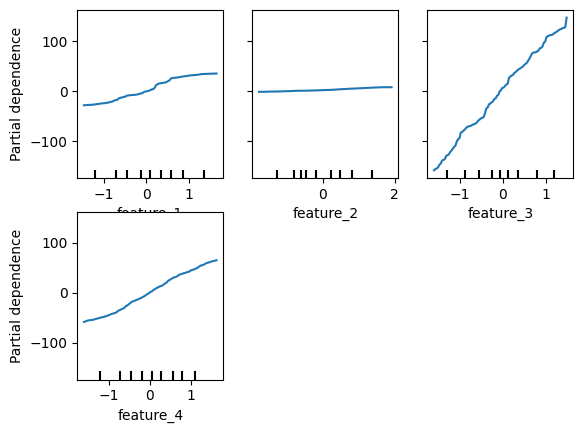

In [40]:
PartialDependenceDisplay.from_estimator(
    model,
    X_test,
    features=[0,1,2,3]
)

plt.show()

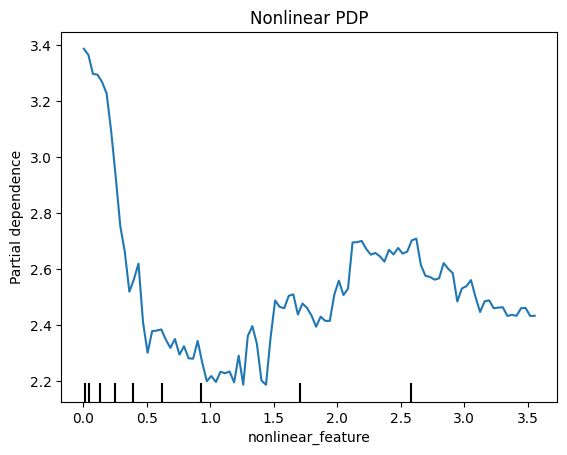

In [41]:
X["nonlinear_feature"] = X["feature_1"]**2

model.fit(X_train, y_train)

PartialDependenceDisplay.from_estimator(
    model,
    X_test,
    features=["nonlinear_feature"]
)

plt.title("Nonlinear PDP")
plt.show()

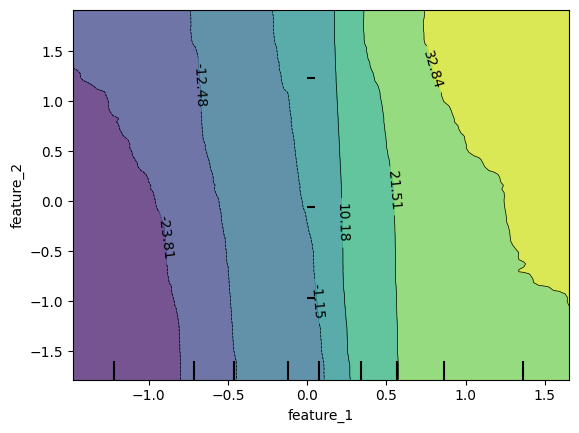

In [42]:
PartialDependenceDisplay.from_estimator(
    model,
    X_test,
    features=[("feature_1","feature_2")]
)

plt.show()

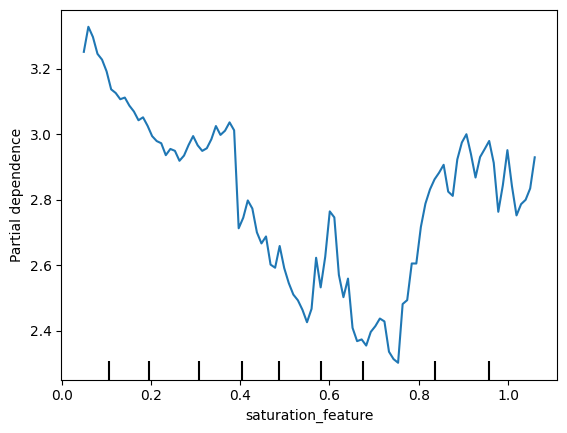

In [43]:
X["saturation_feature"] = np.log(np.abs(X["feature_1"]) + 1)
PartialDependenceDisplay.from_estimator(
    model,
    X_test,
    features=["saturation_feature"]
)

plt.show()

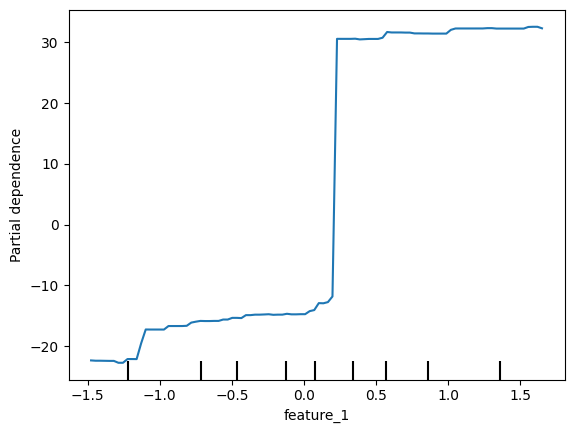

In [44]:
from sklearn.tree import DecisionTreeRegressor

overfit_model = DecisionTreeRegressor(max_depth=20)

overfit_model.fit(X_train, y_train)

PartialDependenceDisplay.from_estimator(
    overfit_model,
    X_test,
    features=[0]
)
plt.show()

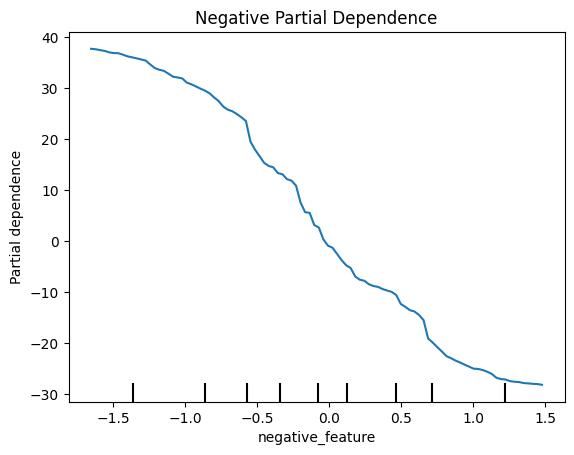

In [45]:
PartialDependenceDisplay.from_estimator(
    model,
    X_test,
    features=["negative_feature"]
)

plt.title("Negative Partial Dependence")
plt.show()

# Key Observations

This notebook demonstrates how Partial Dependence Plots (PDPs) help interpret the functional behavior learned by machine learning models.

Several important patterns were observed.

---

## 1. Step-Like Behavior in Tree Models

Random Forest models produce **step-like PDP curves** because individual decision trees generate **piecewise constant predictions**.

Predictions change only when feature values cross learned split thresholds.

Averaging across many trees smooths these steps but the underlying structure remains piecewise.

---

## 2. Nonlinear Relationships

By introducing a quadratic feature, we observed that tree-based models can capture **nonlinear relationships** between features and predictions.

Partial dependence plots reveal these nonlinear patterns clearly.

---

## 3. Diminishing Returns

Certain features may produce **diminishing marginal effects**, where increasing the feature initially increases predictions but the impact gradually levels off.

PDPs help visualize these saturation effects.

---

## 4. Flat Partial Dependence

A flat PDP indicates that varying the feature does not significantly change model predictions.

This suggests the model does not rely strongly on that feature for prediction.

---

## 5. Interaction Effects

When features interact, a standard PDP averages predictions across different feature combinations.

This can hide interaction effects.

Interaction PDPs or Individual Conditional Expectation (ICE) plots can reveal these interactions more clearly.

---

# Interpretation

Partial dependence plots provide insight into **how machine learning models translate feature values into predictions**.

They allow us to:

- visualize nonlinear relationships
- detect diminishing returns
- identify potential overfitting patterns
- analyze feature interactions

However, PDPs must be interpreted carefully because:

- unrealistic feature combinations may be evaluated
- correlated features can distort interpretation
- interaction effects may be averaged out

---

# Connection to Other Interpretability Tools

Partial dependence plots complement other interpretability techniques:

| Method | Purpose |
|------|------|
| Feature Importance | Identify which features influence predictions |
| Partial Dependence | Understand how features influence predictions |
| SHAP Values | Explain individual predictions |

Together these tools provide a more complete understanding of model behavior.

---

# Next Step

The next stage in the interpretability module introduces **SHAP values**, which provide theoretically grounded explanations for individual predictions based on cooperative game theory.

SHAP combines:

- global feature importance
- local prediction explanations
- additive feature contributions

This allows a deeper understanding of how models produce specific predictions.